In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [2]:
df = pd.read_csv("titanic_toy.csv")

In [3]:
df.head()

,Age,Fare,Family,Survived
0,22.0,7.2500,1,0
1,38.0,71.2833,1,1
2,26.0,7.9250,0,1
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0


In [4]:
df.isnull().sum()

Age         177
Fare         45
Family        0
Survived      0
dtype: int64

In [5]:
df.isnull().mean()*100

Age         19.865320
Fare         5.050505
Family       0.000000
Survived     0.000000
dtype: float64

In [6]:
X = df.drop("Survived", axis =1)
y = df["Survived"]

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [9]:
X_train.head()

,Age,Fare,Family
331,45.5,28.5000,0
733,23.0,13.0000,0
382,32.0,7.9250,0
704,26.0,7.8542,1
813,6.0,31.2750,6


In [10]:
X_train.shape, X_test.shape

((712, 3), (179, 3))

In [12]:
X_train.isnull().mean()*100

Age       19.662921
Fare       5.056180
Family     0.000000
dtype: float64

In [13]:
X_test.isnull().mean()*100

Age       20.670391
Fare       5.027933
Family     0.000000
dtype: float64

In [14]:
Age_mean = X_train["Age"].mean()
Age_median = X_train["Age"].median()

Fare_mean = X_train["Fare"].mean()
Fare_median = X_train["Fare"].mean()

In [15]:
X_train["mean_age"] = X_train["Age"].fillna(Age_mean)
X_train["median_age"] = X_train["Age"].fillna(Age_median)

X_train["mean_fare"] = X_train["Fare"].fillna(Fare_mean)
X_train["median_fare"] = X_train["Fare"].fillna(Fare_median)

In [17]:
X_train.sample(5)

,Age,Fare,Family,mean_age,median_age,mean_fare,median_fare
181,NaN,15.0500,0,29.498846,28.0,15.050000,15.050000
237,8.0,26.2500,2,8.000000,8.0,26.250000,26.250000
24,8.0,21.0750,4,8.000000,8.0,21.075000,21.075000
513,54.0,NaN,1,54.000000,54.0,32.517788,32.517788
663,36.0,7.4958,0,36.000000,36.0,7.495800,7.495800


In [19]:
print("Original age variance: ", X_train["Age"].var())
print("age variance after mean impute: ", X_train["mean_age"].var())
print("age variance after median impute: ", X_train["median_age"].var())

Original age variance:  210.2517072477435
age variance after mean impute:  168.85193366872227
age variance after median impute:  169.20731007048155


In [20]:
print("Original fare variance: ", X_train["Fare"].var())
print("fare variance after mean impute: ", X_train["mean_fare"].var())
print("fare variance after median impute: ", X_train["median_fare"].var())

Original fare variance:  2761.0314349486343
fare variance after mean impute:  2621.232374951235
fare variance after median impute:  2621.232374951235


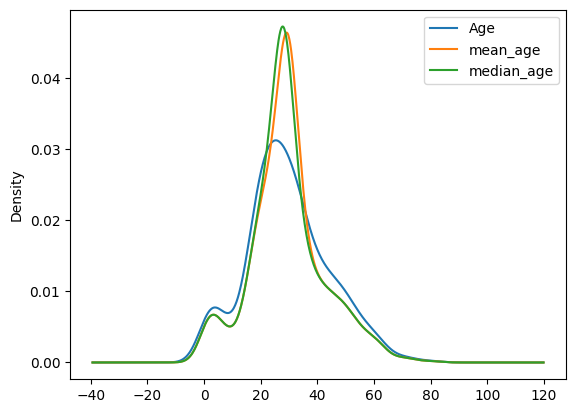

In [25]:
fig = plt.figure()
ax = fig.add_subplot(111)

X_train["Age"].plot(kind="kde", ax=ax)
X_train["mean_age"].plot(kind="kde", ax=ax)
X_train["median_age"].plot(kind="kde", ax=ax)

lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc="best")
plt.show()

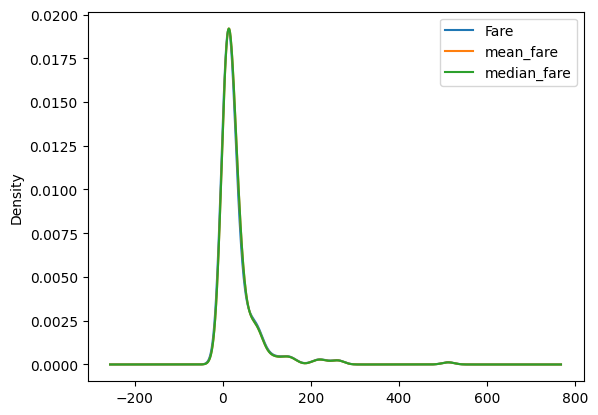

In [26]:
fig = plt.figure()
ax = fig.add_subplot(111)

X_train["Fare"].plot(kind="kde", ax=ax)
X_train["mean_fare"].plot(kind="kde", ax=ax)
X_train["median_fare"].plot(kind="kde", ax=ax)

lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc="best")
plt.show()

In [27]:
X_train.cov()

,Age,Fare,Family,mean_age,median_age,mean_fare,median_fare
Age,210.251707,75.481375,-6.993325,210.251707,210.251707,71.193767,71.193767
Fare,75.481375,2761.031435,18.599163,60.224654,63.938058,2761.031435,2761.031435
Family,-6.993325,18.599163,2.830892,-5.616299,-5.587710,17.657433,17.657433
mean_age,210.251707,60.224654,-5.616299,168.851934,168.851934,57.175304,57.175304
median_age,210.251707,63.938058,-5.587710,168.851934,169.207310,60.700688,60.700688
mean_fare,71.193767,2761.031435,17.657433,57.175304,60.700688,2621.232375,2621.232375
median_fare,71.193767,2761.031435,17.657433,57.175304,60.700688,2621.232375,2621.232375


In [28]:
X_train.corr()

,Age,Fare,Family,mean_age,median_age,mean_fare,median_fare
Age,1.000000,0.091482,-0.319651,1.000000,1.000000,0.088944,0.088944
Fare,0.091482,1.000000,0.207193,0.088151,0.093496,1.000000,1.000000
Family,-0.319651,0.207193,1.000000,-0.256883,-0.255307,0.204981,0.204981
mean_age,1.000000,0.088151,-0.256883,1.000000,0.998949,0.085941,0.085941
median_age,1.000000,0.093496,-0.255307,0.998949,1.000000,0.091145,0.091145
mean_fare,0.088944,1.000000,0.204981,0.085941,0.091145,1.000000,1.000000
median_fare,0.088944,1.000000,0.204981,0.085941,0.091145,1.000000,1.000000


<Axes: >

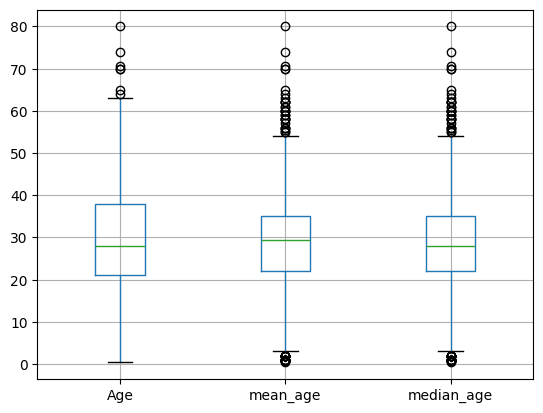

In [29]:
X_train[["Age", "mean_age", "median_age"]].boxplot()

<Axes: >

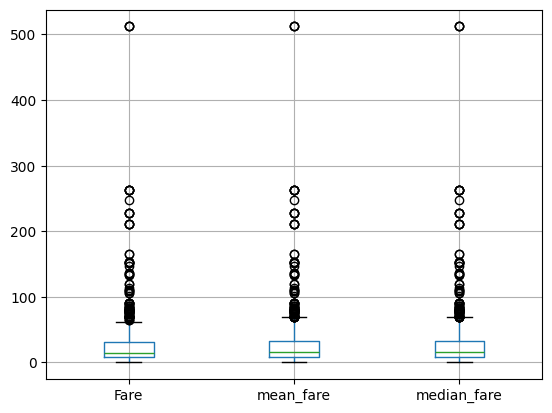

In [30]:
X_train[["Fare", "mean_fare", "median_fare"]].boxplot()

# Using Sklearn

In [31]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [32]:
imputer1 = SimpleImputer(strategy="mean")
imputer2 = SimpleImputer(strategy="median")

In [34]:
trf = ColumnTransformer([
    ("impute1", imputer1, ["Age"]),
    ("impute2", imputer2, ["Fare"])
], remainder="passthrough")

In [36]:
trf.fit(X_train)

ColumnTransformer(remainder='passthrough',
                  transformers=[('impute1', SimpleImputer(), ['Age']),
                                ('impute2', SimpleImputer(strategy='median'),
                                 ['Fare'])])

In [39]:
trf.named_transformers_["impute1"].statistics_

array([29.49884615])

In [40]:
trf.named_transformers_["impute2"].statistics_

array([14.4])

In [41]:
X_train_trf = trf.transform(X_train)
X_test_trf = trf.transform(X_test)

In [42]:
X_train_trf

array([[ 45.5   ,  28.5   ,   0.    ],
       [ 23.    ,  13.    ,   0.    ],
       [ 32.    ,   7.925 ,   0.    ],
       ...,
       [ 41.    ,  14.4   ,   2.    ],
       [ 14.    , 120.    ,   3.    ],
       [ 21.    ,  77.2875,   1.    ]])